# IBS6 Industrial Analytics — Phase 2: XGBoost Predictive Model

## Delivery Delay Prediction Using Extreme Gradient Boosting (XGBoost)

---

## 1. Project Introduction & Overview

### 1.1 Project Information
| Item | Detail |
| :--- | :--- |
| **Course** | IBS6 — Industrial Analytics |
| **Project Team** | Maulik Chopda · Nibakaran Veeramuththu · Kasun Ranwalage · Basim Siddiqui |
| **Algorithm** | Extreme Gradient Boosting (XGBoost) — Challenger Model |
| **Dataset** | `Delivery_Logistics_Processed.csv` |
| **Target Variable** | `delayed` (0 = On-Time · 1 = Delayed) |
| **Business Objective** | Build an Early Warning System that predicts SLA breach risk **before dispatch** |

---

### 1.2 Executive Summary
In Phase 1 (Milestone Presentation), we diagnosed a **reactive logistics network** where delivery failures are identified only after SLA breach. Phase 1 established a baseline delay rate of approximately **27%** using the raw `Delivery_Logistics.csv` dataset and its original `delayed` labels.

This notebook implements **Phase 2**: a rigorous, end-to-end XGBoost classification pipeline on the engineered dataset `Delivery_Logistics_Processed.csv`. The processed file applies Task 4 data engineering rules — outlier removal and a time-based delay definition (`actual delivery time > expected delivery time`) — yielding a **22.1% SLA breach rate** across **24,745** validated records.

Disclaimer: Artificial Intelligence tools were utilized during this project strictly as supplementary aids for code optimization, error debugging, and conceptual comprehension. All final architectures and strategic decisions were independently validated by me.


---

### 1.3 Notebook Structure
| Section | Topic | Purpose |
| :---: | :--- | :--- |
| **1** | Project Introduction | Overview, executive summary, and notebook structure |
| **2** | Environment Setup | Import libraries and configure visualization standards |
| **3** | Data Loading | Ingest processed dataset and verify structural integrity |
| **4** | Exploratory Data Analysis | Profile features, distributions, and data types |
| **5** | Target Profiling | Quantify class imbalance and compute `scale_pos_weight` |
| **6** | Data Leakage Audit | Remove post-dispatch variables to protect model validity |
| **7** | Feature Preparation | Construct the predictive feature matrix (X) and target (y) |
| **8** | Correlation Analysis | Identify strongest pre-dispatch predictors of delay |
| **9** | Train-Test Split | Stratified 80/20 partition for unbiased evaluation |
| **10** | Baseline XGBoost | Train initial model with default hyperparameters |
| **11** | Cross-Validation | 5-fold CV to assess model stability |
| **12** | Hyperparameter Tuning | GridSearchCV to optimize model performance |
| **13** | Final Evaluation | Classification metrics on held-out test set |
| **14** | Confusion Matrix | Visual breakdown of prediction errors |
| **15** | ROC Curve & AUC | Global discrimination capacity across thresholds |
| **16** | Precision-Recall Curve | Imbalance-aware performance diagnostic |
| **17** | Feature Importance | Rank operational drivers of delay risk |
| **18** | Probability Distribution | Validate class separation in predicted scores |
| **19** | Threshold Optimization | Select operational cutoff for deployment |
| **20** | Inference Demo | Simulate real-time pre-dispatch prediction |
| **21** | Conclusions | Summary of findings and model deployment |

---


---
## 2. Environment Setup & Library Imports

Before any analysis begins, we establish a reproducible computational environment. This step imports all libraries required for data manipulation, machine learning, model evaluation, and academic-quality visualization.

### 2.1 Libraries Used
| Category | Library | Role in This Pipeline |
| :--- | :--- | :--- |
| Data Handling | `pandas`, `numpy` | Load, transform, and numerically process delivery records |
| Machine Learning | `scikit-learn` | Train/test splitting, cross-validation, metrics, GridSearchCV |
| Algorithm | `xgboost` | Gradient boosting classifier — our primary predictive engine |
| Visualization | `matplotlib`, `seaborn` | Charts, heatmaps, and distribution plots for presentation |
| Model Persistence | `joblib` | Serialize the trained model for deployment |

### 2.2 Design Decisions
- **Warnings suppressed** to keep notebook output clean for presentation review.
- **Fixed random seed (`random_state=42`)** applied throughout to guarantee reproducible results across runs.
- **Consistent plot theme** ensures all figures follow the same visual standard for the final report.


In [3]:
# ============================================================
# STEP 1: Import Libraries
# ============================================================
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
)
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve, average_precision_score
)

# XGBoost
import xgboost as xgb

# Plot styling
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'font.size': 11, 'figure.figsize': (10, 6)})

print("Step 1 Complete: All libraries imported successfully.")
print(f"XGBoost version: {xgb.__version__}")


Step 1 Complete: All libraries imported successfully.
XGBoost version: 3.1.2


---
## 3. Data Loading & Integrity Validation

We load `Delivery_Logistics_Processed.csv` — the output of our Phase 1 data engineering pipeline (Task 4). This file contains cleaned, scaled, and one-hot encoded features ready for tree-based modeling.

### 3.1 Why This File (Not the Raw CSV)?
| Dataset | Rows | Delay Rate | Definition of `delayed` |
| :--- | :---: | :---: | :--- |
| `Delivery_Logistics.csv` (raw) | 25,000 | ~26.7% | Original business label (`yes` / `no`) |
| `Delivery_Logistics_Processed.csv` | 24,745 | ~22.1% | Recalculated: `delivery_time_raw > expected_time_raw` |

The processed dataset removes **255 records** with unrealistic average speeds (≥ 150 km/h) and applies a **strict, time-based SLA rule** for the target variable. This ensures our model learns from mathematically consistent labels aligned with actual vs. expected delivery duration.

### 3.2 Integrity Checks Performed
1. **Row and column count** — confirm dataset dimensions match engineering documentation.
2. **Missing value audit** — verify zero null entries remain after preprocessing.
3. **Duplicate detection** — ensure no repeated delivery records contaminate training.
4. **Preview inspection** — visually confirm column structure and data types.


In [5]:
# ============================================================
# STEP 2: Load Dataset
# ============================================================
FILE_PATH = 'Delivery_Logistics_Processed.csv'

df = pd.read_csv(FILE_PATH)

print("=" * 60)
print("DATASET LOADED SUCCESSFULLY")
print("=" * 60)
print(f"Rows (deliveries):    {df.shape[0]:,}")
print(f"Columns (features):   {df.shape[1]}")
print(f"Missing values:       {df.isnull().sum().sum()}")
print(f"Duplicate rows:       {df.duplicated().sum()}")
print("=" * 60)

df.head()


DATASET LOADED SUCCESSFULLY
Rows (deliveries):    24,745
Columns (features):   45
Missing values:       0
Duplicate rows:       0


,distance_km,package_weight_kg,delivery_time_hours,expected_time_hours,delayed,delivery_rating,delivery_cost,avg_speed_kmh,delivery_partner_blue dart,delivery_partner_delhivery,...,region_west,weather_condition_cold,weather_condition_foggy,weather_condition_hot,weather_condition_rainy,weather_condition_stormy,delivery_status_delivered,delivery_status_failed,delivery_time_raw,expected_time_raw
0,1.693588,1.519280,0.545792,-0.676878,0,3,1632.7206,0.908631,False,True,...,True,False,False,False,False,False,True,False,8,8
1,-0.725185,1.549213,-1.394717,-1.338729,0,5,640.1700,1.497928,False,False,...,False,True,False,False,False,False,True,False,2,3
2,1.419522,0.122154,1.192628,0.382084,0,4,1448.1700,0.158093,False,False,...,False,False,False,False,True,False,True,False,10,16
3,1.375205,-0.866345,-0.101044,-0.676878,0,3,1486.5700,1.509445,False,False,...,False,True,False,False,False,False,True,False,6,8
4,1.223595,0.827330,0.869210,0.382084,0,4,1394.5600,0.248097,False,False,...,False,False,True,False,False,False,True,False,9,16


---
## 4. Exploratory Data Analysis (EDA)

Exploratory Data Analysis is the foundation of any credible industrial analytics project. Before training a model, we must understand the **shape, scale, and statistical behavior** of every feature in our dataset.

### 4.1 Objectives of This Step
1. **Catalog all variables** — list every column with its data type (numerical, boolean/one-hot).
2. **Summarize numerical features** — compute mean, standard deviation, min, max, and quartiles.
3. **Visualize key distributions** — plot histograms for distance, weight, expected time, and cost.

### 4.2 Features Under Review
| Feature | Type | Business Meaning |
| :--- | :--- | :--- |
| `distance_km` | Numerical (scaled) | Route length — primary complexity driver |
| `package_weight_kg` | Numerical (scaled) | Load weight — affects vehicle capacity and handling time |
| `expected_time_hours` | Numerical (scaled) | Promised SLA window agreed at dispatch |
| `delivery_cost` | Numerical | Financial value of the shipment |
| One-hot columns | Binary (0/1) | Encoded categories: partner, vehicle, weather, region, etc. |

Understanding these distributions helps us interpret model behavior later and validates that preprocessing was applied correctly.


In [7]:
# ============================================================
# STEP 3a: Data Types & Column Overview
# ============================================================
print("Column Data Types:")
print("-" * 40)
print(df.dtypes.value_counts())
print()
print("All Columns:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:2d}. {col}")


Column Data Types:
----------------------------------------
bool       35
float64     6
int64       4
Name: count, dtype: int64

All Columns:
   1. distance_km
   2. package_weight_kg
   3. delivery_time_hours
   4. expected_time_hours
   5. delayed
   6. delivery_rating
   7. delivery_cost
   8. avg_speed_kmh
   9. delivery_partner_blue dart
  10. delivery_partner_delhivery
  11. delivery_partner_dhl
  12. delivery_partner_ecom express
  13. delivery_partner_ekart
  14. delivery_partner_fedex
  15. delivery_partner_shadowfax
  16. delivery_partner_xpressbees
  17. package_type_clothing
  18. package_type_cosmetics
  19. package_type_documents
  20. package_type_electronics
  21. package_type_fragile items
  22. package_type_furniture
  23. package_type_groceries
  24. package_type_pharmacy
  25. vehicle_type_ev bike
  26. vehicle_type_ev van
  27. vehicle_type_scooter
  28. vehicle_type_truck
  29. vehicle_type_van
  30. delivery_mode_same day
  31. delivery_mode_standard
  32. delive

In [8]:
# ============================================================
# STEP 3b: Summary Statistics (Numerical Columns)
# ============================================================
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"Numerical columns ({len(numerical_cols)}):")
display(df[numerical_cols].describe().T.round(3))


Numerical columns (10):


,count,mean,std,min,25%,50%,75%,max
distance_km,24745.0,-0.000,1.000,-1.728,-0.860,0.006,0.862,1.695
package_weight_kg,24745.0,-0.000,1.000,-1.703,-0.868,-0.001,0.871,1.697
delivery_time_hours,24745.0,-0.000,1.000,-1.718,-0.748,-0.101,0.546,4.103
expected_time_hours,24745.0,0.000,1.000,-1.471,-0.677,-0.677,0.382,1.441
delayed,24745.0,0.221,0.415,0.000,0.000,0.000,0.000,1.000
delivery_rating,24745.0,3.660,1.152,1.000,3.000,4.000,5.000,5.000
delivery_cost,24745.0,871.797,432.595,95.667,501.920,875.330,1242.470,1632.721
avg_speed_kmh,24745.0,0.000,1.000,-1.907,-0.660,-0.088,0.565,6.658
delivery_time_raw,24745.0,6.312,3.092,1.000,4.000,6.000,8.000,19.000
expected_time_raw,24745.0,13.114,7.555,2.000,8.000,8.000,16.000,24.000


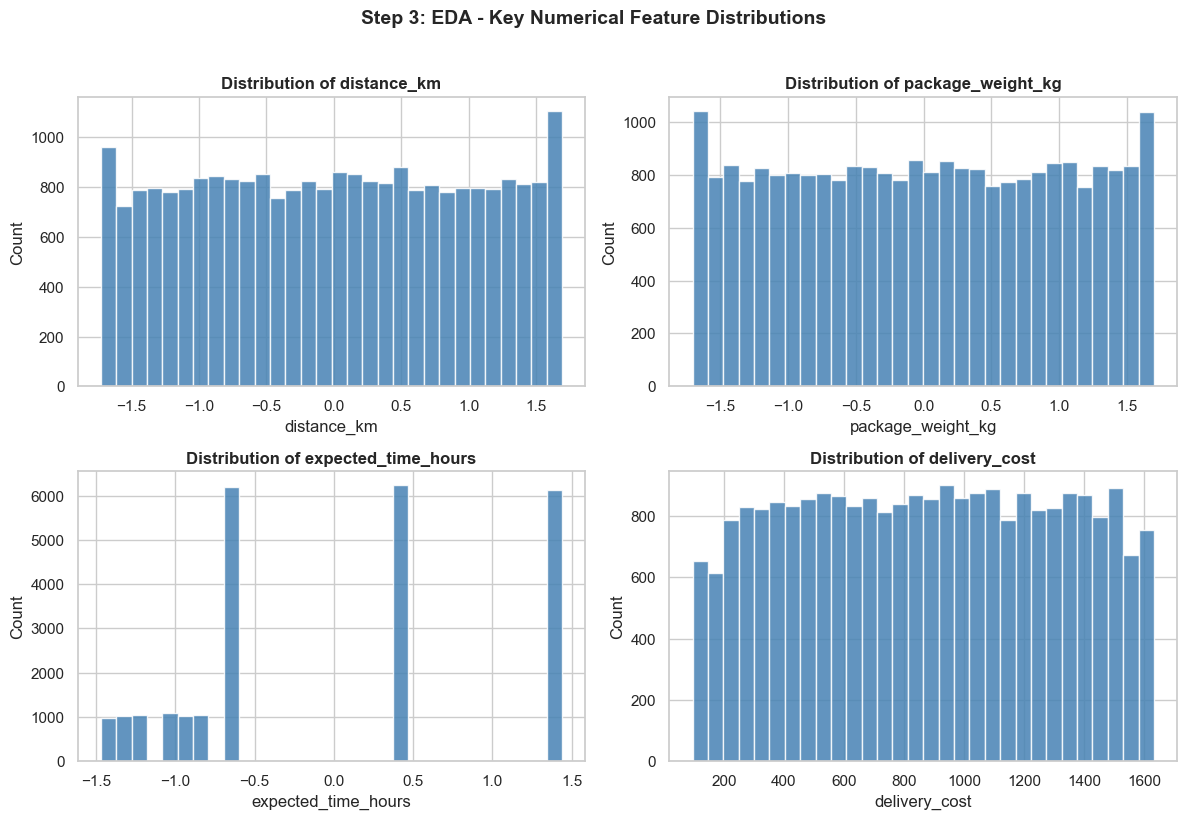

In [9]:
# ============================================================
# STEP 3c: Distribution of Key Numerical Features
# ============================================================
key_features = ['distance_km', 'package_weight_kg', 'expected_time_hours', 'delivery_cost']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

for ax, col in zip(axes, key_features):
    data = df[col].dropna()
    ax.hist(data, bins=30, color='steelblue', edgecolor='white', alpha=0.85)
    ax.set_title(f'Distribution of {col}', fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')

plt.suptitle('Step 3: EDA - Key Numerical Feature Distributions', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


---
## 5. Target Variable Profiling & Class Imbalance Analysis

The target variable `delayed` is the operational outcome our Early Warning System must predict.

| Value | Meaning | Business Interpretation |
| :---: | :--- | :--- |
| **0** | On-Time | Delivery completed within the expected SLA window |
| **1** | Delayed | Delivery exceeded the expected SLA window |

### 5.1 Class Imbalance — A Critical Modeling Challenge
Real-world logistics data is **structurally imbalanced**: the majority of deliveries arrive on time, while a minority breach SLA. If we train XGBoost without addressing this imbalance, the model will optimize for the majority class and **systematically under-predict delays** — the exact failure mode we must avoid.

### 5.2 Our Mitigation Strategy
We compute the **`scale_pos_weight`** hyperparameter:

$$	ext{scale\_pos\_weight} = rac{	ext{Count of On-Time (Class 0)}}{	ext{Count of Delayed (Class 1)}}$$

This forces XGBoost to assign a heavier penalty to missed delay predictions during training, aligning the model with our business priority: **catch delays before they happen**.

### 5.3 Visual Confirmation
We render a bar chart and pie chart to document the exact class distribution — a mandatory diagnostic for any imbalanced classification project presented to academic review.


TARGET VARIABLE: 'delayed'
On-Time (0):  19,279  (77.91%)
Delayed (1):  5,466  (22.09%)
Total:        24,745

scale_pos_weight for XGBoost: 3.5271


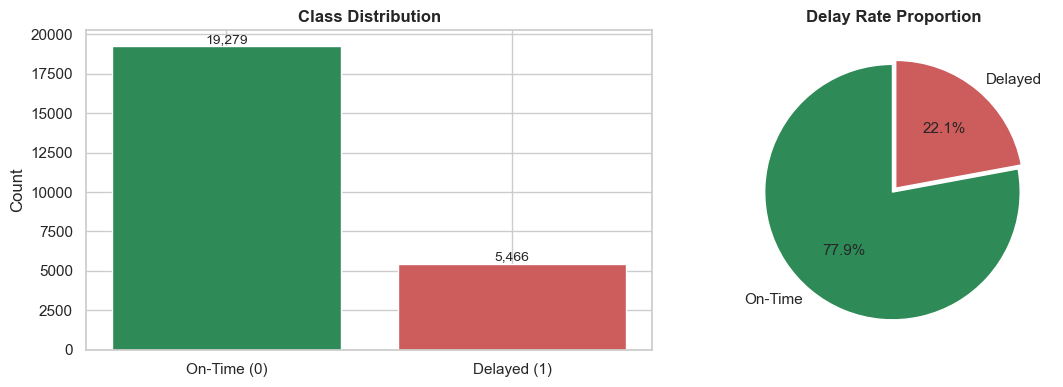

In [11]:
# ============================================================
# STEP 4: Target Variable Analysis
# ============================================================
target_col = 'delayed'

# Ensure target is numeric
if df[target_col].dtype == 'object':
    df[target_col] = df[target_col].astype(str).str.lower().str.strip().map({'yes': 1, 'no': 0})

target_counts = df[target_col].value_counts().sort_index()
total = len(df)
on_time = target_counts.get(0, 0)
delayed = target_counts.get(1, 0)
delay_rate = (delayed / total) * 100

# scale_pos_weight = count(negative) / count(positive)
scale_pos_weight = on_time / delayed

print("=" * 60)
print("TARGET VARIABLE: 'delayed'")
print("=" * 60)
print(f"On-Time (0):  {on_time:,}  ({100 - delay_rate:.2f}%)")
print(f"Delayed (1):  {delayed:,}  ({delay_rate:.2f}%)")
print(f"Total:        {total:,}")
print()
print(f"scale_pos_weight for XGBoost: {scale_pos_weight:.4f}")
print("=" * 60)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

bar_labels = ['On-Time (0)', 'Delayed (1)']
bar_values = [on_time, delayed]
bar_colors = ['#2E8B57', '#CD5C5C']
bars = axes[0].bar(bar_labels, bar_values, color=bar_colors, edgecolor='white')
axes[0].set_title('Class Distribution', fontweight='bold')
axes[0].set_ylabel('Count')
for bar, val in zip(bars, bar_values):
    axes[0].annotate(f'{val:,}', (bar.get_x() + bar.get_width()/2, bar.get_height()),
                     ha='center', va='bottom', fontsize=10)

axes[1].pie([on_time, delayed], labels=['On-Time', 'Delayed'], autopct='%1.1f%%',
            colors=['#2E8B57', '#CD5C5C'], startangle=90, explode=(0.02, 0.02))
axes[1].set_title('Delay Rate Proportion', fontweight='bold')

plt.tight_layout()
plt.show()


---
## 6. Data Leakage Audit & Pre-Dispatch Feature Isolation

> **This is the most critical methodological step in the entire pipeline.**

Our business objective is an **Early Warning System** — a model that predicts delay risk **before a vehicle leaves the warehouse**. Therefore, every feature in our matrix must represent information available **at the moment of dispatch**.

### 6.1 What Is Data Leakage?
Data leakage occurs when the model receives information that would **not exist** at prediction time. If post-delivery variables remain in the feature set, the model achieves artificially perfect accuracy during training but **fails completely in production**.

During initial development, we observed near-100% accuracy — a clear leakage signal. The audit below identifies and removes all downstream variables.

### 6.2 Columns Removed and Rationale
| Removed Column | Category | Reason for Removal |
| :--- | :--- | :--- |
| `delivery_time_hours` | Post-dispatch | Actual transit duration — unknown before delivery completes |
| `delivery_time_raw` | Post-dispatch | Raw actual delivery time in hours |
| `expected_time_raw` | Redundant | Duplicate of scaled `expected_time_hours` |
| `delivery_rating` | Post-dispatch | Customer satisfaction score — collected after delivery |
| `avg_speed_kmh` | Derived leakage | Computed from actual delivery duration |
| `delivery_status_delivered` | Outcome proxy | Reveals whether delivery succeeded |
| `delivery_status_failed` | Outcome proxy | Reveals whether delivery failed |

### 6.3 Approved Feature Set
After the purge, **37 pre-dispatch features** remain — distance, weight, expected time, cost, delivery partner, vehicle type, weather, region, package type, and delivery mode. These represent the complete information available to a dispatch manager at routing time.


In [13]:
# ============================================================
# STEP 5: Remove Leakage Columns
# ============================================================
LEAKAGE_COLUMNS = [
    'delivery_time_hours',
    'delivery_time_raw',
    'expected_time_raw',
    'delivery_rating',
    'avg_speed_kmh',
    'delivery_status_delivered',
    'delivery_status_failed',
]

existing_leakage = [c for c in LEAKAGE_COLUMNS if c in df.columns]
df_model = df.drop(columns=existing_leakage)

print("=" * 60)
print("DATA LEAKAGE PURGE")
print("=" * 60)
print(f"Removed columns ({len(existing_leakage)}):")
for col in existing_leakage:
    print(f"  - {col}")
print()
print(f"Remaining columns: {df_model.shape[1]}")
print(f"Predictive features (excl. target): {df_model.shape[1] - 1}")
print("=" * 60)


DATA LEAKAGE PURGE
Removed columns (7):
  - delivery_time_hours
  - delivery_time_raw
  - expected_time_raw
  - delivery_rating
  - avg_speed_kmh
  - delivery_status_delivered
  - delivery_status_failed

Remaining columns: 38
Predictive features (excl. target): 37


---
## 7. Feature Matrix Preparation

With leakage columns removed, we construct the final modeling inputs.

### 7.1 Process
1. **Separate predictors from target** — `X` contains all features; `y` contains `delayed`.
2. **Convert boolean columns to integers** — one-hot encoded flags (`True`/`False`) are mapped to `1`/`0` for XGBoost compatibility.
3. **Verify matrix dimensions** — confirm the feature count and row count before splitting.

### 7.2 Resulting Structure
| Component | Description |
| :--- | :--- |
| **X (Feature Matrix)** | All pre-dispatch predictors — numerical + one-hot encoded |
| **y (Target Vector)** | Binary delay label — 0 (On-Time) or 1 (Delayed) |

No additional scaling is required. XGBoost is a tree-based algorithm and is **scale-invariant** — it partitions feature space using threshold splits rather than distance calculations.


In [15]:
# ============================================================
# STEP 6: Prepare X and y
# ============================================================
X = df_model.drop(columns=[target_col])
y = df_model[target_col]

# Convert boolean columns to int
bool_cols = X.select_dtypes(include='bool').columns
X[bool_cols] = X[bool_cols].astype(int)

print("=" * 60)
print("FEATURE MATRIX READY")
print("=" * 60)
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Numerical features:  {X.select_dtypes(include=[np.number]).shape[1]}")
print(f"Boolean (OHE) flags: {len(bool_cols)}")
print("=" * 60)

print("\nFirst 5 rows of feature matrix:")
X.head()


FEATURE MATRIX READY
X shape: (24745, 37)
y shape: (24745,)
Numerical features:  37
Boolean (OHE) flags: 33

First 5 rows of feature matrix:


,distance_km,package_weight_kg,expected_time_hours,delivery_cost,delivery_partner_blue dart,delivery_partner_delhivery,delivery_partner_dhl,delivery_partner_ecom express,delivery_partner_ekart,delivery_partner_fedex,...,delivery_mode_two day,region_east,region_north,region_south,region_west,weather_condition_cold,weather_condition_foggy,weather_condition_hot,weather_condition_rainy,weather_condition_stormy
0,1.693588,1.519280,-0.676878,1632.7206,0,1,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
1,-0.725185,1.549213,-1.338729,640.1700,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2,1.419522,0.122154,0.382084,1448.1700,0,0,0,0,0,0,...,1,1,0,0,0,0,0,0,1,0
3,1.375205,-0.866345,-0.676878,1486.5700,0,0,1,0,0,0,...,0,1,0,0,0,1,0,0,0,0
4,1.223595,0.827330,0.382084,1394.5600,0,0,1,0,0,0,...,1,0,1,0,0,0,1,0,0,0


---
## 8. Correlation Analysis with Target Variable

Correlation analysis reveals which pre-dispatch features have the strongest **linear relationship** with delivery delay. While XGBoost captures non-linear patterns, this step provides interpretable insight for the business audience and validates feature relevance before modeling.

### 8.1 Method
We compute the **Pearson correlation coefficient** between each numerical feature and the `delayed` target, then rank features from strongest positive correlation to strongest negative.

### 8.2 How to Interpret Results
| Correlation Sign | Interpretation |
| :--- | :--- |
| **Positive (+)** | Higher feature values associate with higher delay probability |
| **Negative (−)** | Higher feature values associate with lower delay probability |
| **Near zero** | Feature has weak linear association with delay (may still be useful non-linearly) |

Features with the highest absolute correlation are prime candidates for operational intervention — for example, if `distance_km` shows strong positive correlation, long-haul routes may require additional buffer time in the SLA contract.


Correlation with 'delayed' (sorted):
----------------------------------------
delivery_cost                    0.1913
weather_condition_stormy         0.1673
distance_km                      0.1627
weather_condition_rainy          0.1240
weather_condition_foggy          0.0302
delivery_partner_xpressbees      0.0192
delivery_mode_same day           0.0124
region_west                      0.0083
package_type_pharmacy            0.0066
package_type_groceries           0.0053
delivery_partner_ecom express    0.0035
vehicle_type_van                 0.0030
package_type_electronics         0.0028
vehicle_type_truck               0.0028
delivery_partner_shadowfax       0.0023
delivery_partner_ekart           0.0021
package_type_cosmetics           0.0021
package_type_documents           0.0013
package_type_clothing            0.0007
region_south                    -0.0002
vehicle_type_ev bike            -0.0004
delivery_partner_dhl            -0.0009
delivery_partner_blue dart      -0.0009
pa

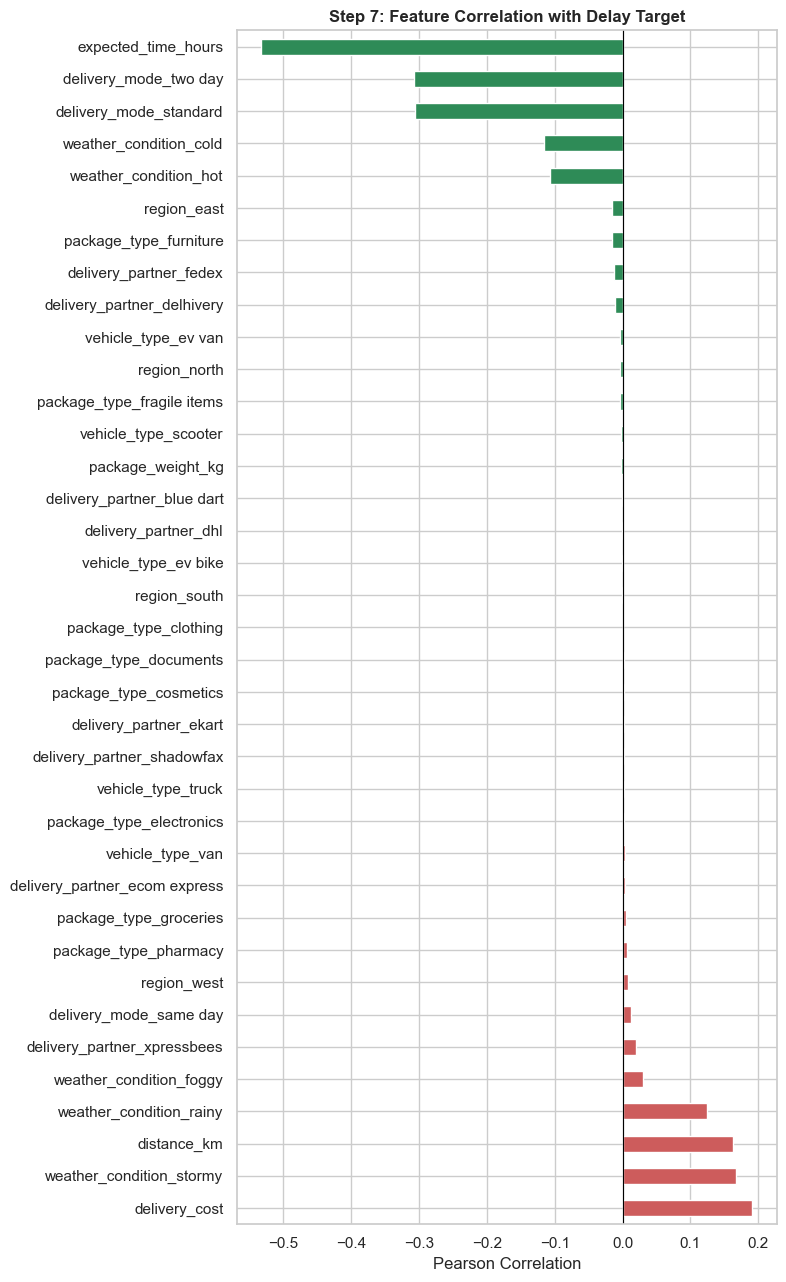

In [17]:
# ============================================================
# STEP 7: Correlation with Target
# ============================================================
num_for_corr = X.select_dtypes(include=[np.number]).columns.tolist()
corr_with_target = df_model[num_for_corr + [target_col]].corr()[target_col].drop(target_col).sort_values(ascending=False)

print("Correlation with 'delayed' (sorted):")
print("-" * 40)
print(corr_with_target.round(4))

# Bar plot
plt.figure(figsize=(8, max(4, len(corr_with_target) * 0.35)))
colors = ['#CD5C5C' if v > 0 else '#2E8B57' for v in corr_with_target]
corr_with_target.plot(kind='barh', color=colors, edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Step 7: Feature Correlation with Delay Target', fontweight='bold')
plt.xlabel('Pearson Correlation')
plt.tight_layout()
plt.show()


---
## 9. Stratified Train-Test Partitioning

To evaluate model performance on unseen data, we partition the dataset into two disjoint subsets.

### 9.1 Split Configuration
| Parameter | Value | Justification |
| :--- | :---: | :--- |
| Training Set | **80%** | Used for model fitting, cross-validation, and hyperparameter search |
| Test Set | **20%** | Held out completely until final evaluation — simulates production data |
| Split Method | **Stratified** | Preserves the exact on-time/delay ratio in both partitions |
| Random Seed | **42** | Ensures reproducibility for academic review |

### 9.2 Why Stratification Matters
With an imbalanced target (~78% on-time, ~22% delayed), a random split could accidentally place too few delayed records in the test set. Stratification guarantees that both training and testing sets contain a **representative proportion** of each class, producing a statistically valid performance estimate.

### 9.3 Note on Feature Scaling
Unlike Logistic Regression, XGBoost does **not** require StandardScaler. Tree models split on individual feature thresholds and are unaffected by differences in feature magnitude. The dataset is used as-is after preprocessing.


In [19]:
# ============================================================
# STEP 8: Train-Test Split
# ============================================================
RANDOM_STATE = 42
TEST_SIZE = 0.20

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

print("=" * 60)
print("TRAIN-TEST SPLIT (Stratified)")
print("=" * 60)
print(f"Training set: {X_train.shape[0]:,} samples ({100*(1-TEST_SIZE):.0f}%)")
print(f"Testing set:  {X_test.shape[0]:,} samples ({100*TEST_SIZE:.0f}%)")
print(f"Features:     {X_train.shape[1]}")
print()
print(f"Train delay rate: {y_train.mean()*100:.2f}%")
print(f"Test delay rate:  {y_test.mean()*100:.2f}%")
print("=" * 60)


TRAIN-TEST SPLIT (Stratified)
Training set: 19,796 samples (80%)
Testing set:  4,949 samples (20%)
Features:     37

Train delay rate: 22.09%
Test delay rate:  22.09%


---
## 10. Baseline XGBoost Model — Initial Training

We train a **baseline XGBoost classifier** with carefully chosen default hyperparameters. This establishes a performance floor before hyperparameter optimization in Step 11.

### 10.1 XGBoost — Why This Algorithm?
Extreme Gradient Boosting builds an **ensemble of decision trees sequentially**, where each new tree corrects the errors of the previous ones. For logistics data with mixed numerical and categorical features, XGBoost offers:

- Strong performance on **imbalanced** classification tasks
- Built-in handling of **non-linear** feature interactions (e.g., weather × distance)
- Native support for **feature importance** ranking
- Robustness to outliers after preprocessing

### 10.2 Baseline Hyperparameters
| Parameter | Value | Purpose |
| :--- | :---: | :--- |
| `objective` | `binary:logistic` | Binary classification with probability output |
| `eval_metric` | `logloss` | Log-loss optimization during training |
| `scale_pos_weight` | From Step 4 | Penalizes missed delay predictions |
| `n_estimators` | 200 | Number of sequential boosting rounds |
| `max_depth` | 6 | Maximum depth per decision tree |
| `learning_rate` | 0.1 | Shrinkage rate — prevents overfitting per tree |
| `subsample` | 0.8 | Uses 80% of rows per tree (stochastic boosting) |
| `colsample_bytree` | 0.8 | Uses 80% of features per tree |
| `random_state` | 42 | Reproducibility |

### 10.3 Metrics Reported
Accuracy, Precision, Recall, F1 Score, and ROC-AUC on the **held-out test set** provide the baseline benchmark for comparison after tuning.


In [21]:
# ============================================================
# STEP 9: Baseline XGBoost Model
# ============================================================
baseline_model = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    scale_pos_weight=scale_pos_weight,
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=0
)

print("Training baseline XGBoost model...")
baseline_model.fit(X_train, y_train)
print("Training complete.")

# Predictions
y_pred_base = baseline_model.predict(X_test)
y_proba_base = baseline_model.predict_proba(X_test)[:, 1]

print("\n" + "=" * 60)
print("BASELINE MODEL — TEST SET PERFORMANCE")
print("=" * 60)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_base):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_base):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_base):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred_base):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_proba_base):.4f}")
print("=" * 60)


Training baseline XGBoost model...
Training complete.

BASELINE MODEL — TEST SET PERFORMANCE
Accuracy:  0.8905
Precision: 0.6947
Recall:    0.8994
F1 Score:  0.7839
ROC-AUC:   0.9636


---
## 11. Cross-Validation — Model Stability Assessment

A single train-test split can produce optimistic or pessimistic results depending on which records land in each partition. **K-Fold Cross-Validation** provides a more reliable estimate of generalization performance.

### 11.1 Method: 5-Fold Stratified Cross-Validation
1. The training set is divided into **5 equal folds**.
2. In each iteration, **4 folds train** the model and **1 fold validates** it.
3. Every record appears in a validation fold exactly once.
4. The **F1 Score** is recorded for each fold (chosen because it balances Precision and Recall on imbalanced data).

### 11.2 What We Look For
| Indicator | Healthy Model | Unstable Model |
| :--- | :--- | :--- |
| Mean F1 across folds | Consistently high | Low average |
| Standard deviation | Low (< 0.03) | High (> 0.05) |
| Fold-to-fold variance | Similar scores | Large swings |

Low variance across folds confirms the model has **learned generalizable delay patterns** rather than memorizing specific training records.


5-FOLD CROSS-VALIDATION (F1 Score)
  Fold 1: 0.7700
  Fold 2: 0.7802
  Fold 3: 0.7827
  Fold 4: 0.7915
  Fold 5: 0.7939

Mean F1:   0.7837
Std F1:    0.0086


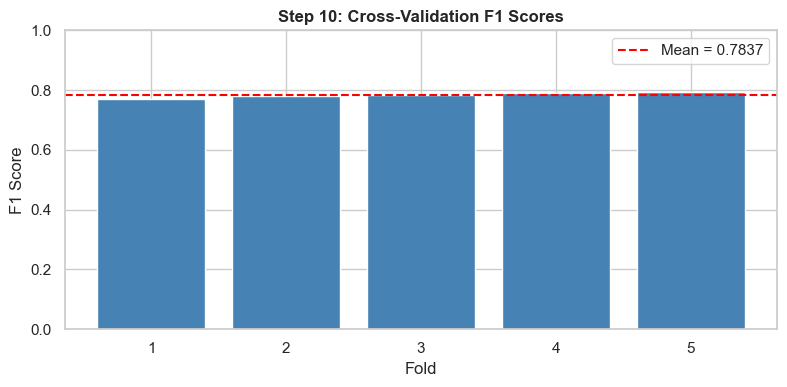

In [23]:
# ============================================================
# STEP 10: 5-Fold Cross-Validation
# ============================================================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_scores = cross_val_score(
    baseline_model, X_train, y_train,
    cv=cv, scoring='f1', n_jobs=-1
)

print("=" * 60)
print("5-FOLD CROSS-VALIDATION (F1 Score)")
print("=" * 60)
for i, score in enumerate(cv_scores, 1):
    print(f"  Fold {i}: {score:.4f}")
print(f"\nMean F1:   {cv_scores.mean():.4f}")
print(f"Std F1:    {cv_scores.std():.4f}")
print("=" * 60)

plt.figure(figsize=(8, 4))
plt.bar(range(1, 6), cv_scores, color='steelblue', edgecolor='white')
plt.axhline(cv_scores.mean(), color='red', linestyle='--', label=f'Mean = {cv_scores.mean():.4f}')
plt.xlabel('Fold')
plt.ylabel('F1 Score')
plt.title('Step 10: Cross-Validation F1 Scores', fontweight='bold')
plt.legend()
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


---
## 12. Hyperparameter Tuning with GridSearchCV

The baseline model uses reasonable defaults, but industrial deployment demands **optimized performance**. We systematically search a hyperparameter grid using `GridSearchCV` with 3-fold stratified cross-validation.

### 12.1 Parameters Under Optimization
| Hyperparameter | Values Tested | Effect |
| :--- | :--- | :--- |
| `max_depth` | 4, 6, 8 | Controls tree complexity — deeper trees capture more interactions but risk overfitting |
| `learning_rate` | 0.05, 0.1 | Step size for each boosting round — lower rates need more trees but generalize better |
| `n_estimators` | 150, 200 | Total number of boosting trees in the ensemble |
| `subsample` | 0.8, 1.0 | Fraction of training rows sampled per tree |
| `colsample_bytree` | 0.8, 1.0 | Fraction of features sampled per tree |

### 12.2 Selection Criterion
The combination achieving the **highest mean F1 Score** across cross-validation folds is selected as the final model configuration. F1 is chosen over Accuracy because missing a delayed delivery (False Negative) carries greater operational cost than a false alarm.


In [25]:
# ============================================================
# STEP 11: Hyperparameter Tuning
# ============================================================
param_grid = {
    'max_depth': [4, 6, 8],
    'learning_rate': [0.05, 0.1],
    'n_estimators': [150, 200],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
}

xgb_tuned = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    scale_pos_weight=scale_pos_weight,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=0
)

print("Running GridSearchCV (this may take a few minutes)...")
grid_search = GridSearchCV(
    estimator=xgb_tuned,
    param_grid=param_grid,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE),
    scoring='f1',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("\n" + "=" * 60)
print("GRID SEARCH RESULTS")
print("=" * 60)
print(f"Best F1 (CV):     {grid_search.best_score_:.4f}")
print(f"Best Parameters:")
for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")
print("=" * 60)

best_model = grid_search.best_estimator_


Running GridSearchCV (this may take a few minutes)...
Fitting 3 folds for each of 48 candidates, totalling 144 fits

GRID SEARCH RESULTS
Best F1 (CV):     0.7800
Best Parameters:
  colsample_bytree: 1.0
  learning_rate: 0.05
  max_depth: 8
  n_estimators: 200
  subsample: 0.8


---
## 13. Final Model Evaluation — Test Set Performance

The tuned XGBoost model is evaluated on the **20% held-out test set** that was never seen during training or hyperparameter search. This provides an unbiased estimate of how the model will perform on new delivery records in production.

### 13.1 Metrics Computed
| Metric | Formula (Concept) | Business Meaning |
| :--- | :--- | :--- |
| **Accuracy** | Correct predictions / Total | Overall correctness — can be misleading on imbalanced data |
| **Precision** | TP / (TP + FP) | Of flagged delays, how many were truly delayed? |
| **Recall** | TP / (TP + FN) | Of all actual delays, how many did we catch? |
| **F1 Score** | Harmonic mean of Precision & Recall | Balanced performance measure for imbalanced classes |
| **ROC-AUC** | Area under ROC curve | Global ranking ability across all probability thresholds |
| **Average Precision** | Area under PR curve | Precision-recall performance summary |

### 13.2 Classification Report
A detailed per-class breakdown (On-Time vs. Delayed) is printed, showing Precision, Recall, F1, and Support for each class — the standard format expected in academic ML evaluation.


In [27]:
# ============================================================
# STEP 12: Final Model Evaluation
# ============================================================
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

print("=" * 60)
print("TUNED XGBOOST — TEST SET METRICS")
print("=" * 60)
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_proba):.4f}")
print(f"Avg Prec:  {average_precision_score(y_test, y_proba):.4f}")
print("=" * 60)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['On-Time (0)', 'Delayed (1)']))


TUNED XGBOOST — TEST SET METRICS
Accuracy:  0.8901
Precision: 0.6918
Recall:    0.9058
F1 Score:  0.7845
ROC-AUC:   0.9645
Avg Prec:  0.8790

Classification Report:
              precision    recall  f1-score   support

 On-Time (0)       0.97      0.89      0.93      3856
 Delayed (1)       0.69      0.91      0.78      1093

    accuracy                           0.89      4949
   macro avg       0.83      0.90      0.86      4949
weighted avg       0.91      0.89      0.89      4949



---
## 14. Confusion Matrix — Error Analysis

The confusion matrix decomposes every prediction into four categories, revealing exactly **where the model succeeds and where it fails**.

### 14.1 Matrix Structure
|  | **Predicted: On-Time** | **Predicted: Delayed** |
| :--- | :---: | :---: |
| **Actual: On-Time** | True Negative (TN) ✓ | False Positive (FP) |
| **Actual: Delayed** | **False Negative (FN)** ⚠ | True Positive (TP) ✓ |

### 14.2 Operational Interpretation
| Error Type | Business Impact | Priority |
| :--- | :--- | :--- |
| **False Negative (FN)** | Model missed a delay — SLA breached without warning | **Critical** — must minimize |
| **False Positive (FP)** | Model flagged a safe delivery — unnecessary rerouting cost | Moderate — acceptable trade-off |
| **True Positive (TP)** | Delay correctly predicted — proactive intervention possible | Ideal outcome |
| **True Negative (TN)** | On-time delivery correctly cleared | Ideal outcome |

In logistics, **Recall (catching delays) is prioritized over Precision** because the cost of an undetected SLA breach (customer churn, penalty fees) far exceeds the cost of a precautionary reroute.

Two visualizations are rendered: raw counts and row-normalized percentages for intuitive comparison.


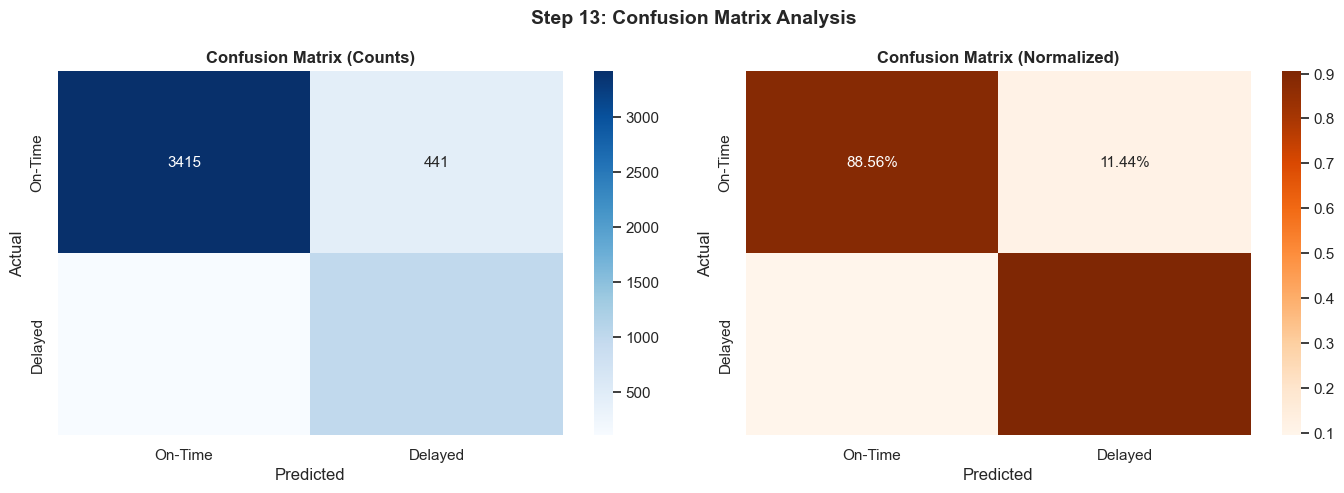

True Negatives:  3,415
False Positives: 441
False Negatives: 103  <- missed delays
True Positives:  990


In [29]:
# ============================================================
# STEP 13: Confusion Matrix
# ============================================================
cm = confusion_matrix(y_test, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['On-Time', 'Delayed'],
            yticklabels=['On-Time', 'Delayed'])
axes[0].set_title('Confusion Matrix (Counts)', fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Normalized
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Oranges', ax=axes[1],
            xticklabels=['On-Time', 'Delayed'],
            yticklabels=['On-Time', 'Delayed'])
axes[1].set_title('Confusion Matrix (Normalized)', fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.suptitle('Step 13: Confusion Matrix Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives:  {tn:,}")
print(f"False Positives: {fp:,}")
print(f"False Negatives: {fn:,}  <- missed delays")
print(f"True Positives:  {tp:,}")


---
## 15. ROC Curve & Area Under Curve (AUC)

The **Receiver Operating Characteristic (ROC) curve** evaluates the model's ability to **rank** deliveries by delay risk across every possible classification threshold.

### 15.1 Axes
| Axis | Metric | Meaning |
| :--- | :--- | :--- |
| X-axis | False Positive Rate | Fraction of on-time deliveries incorrectly flagged |
| Y-axis | True Positive Rate (Recall) | Fraction of actual delays correctly identified |

### 15.2 AUC Interpretation
| AUC Range | Model Quality |
| :--- | :--- |
| 0.90 – 1.00 | Excellent discrimination |
| 0.80 – 0.90 | Good discrimination |
| 0.70 – 0.80 | Acceptable discrimination |
| 0.50 | No better than random guessing |

A model with high AUC can assign higher delay probabilities to truly delayed deliveries regardless of the specific threshold chosen — confirming the Early Warning System has genuine predictive power.


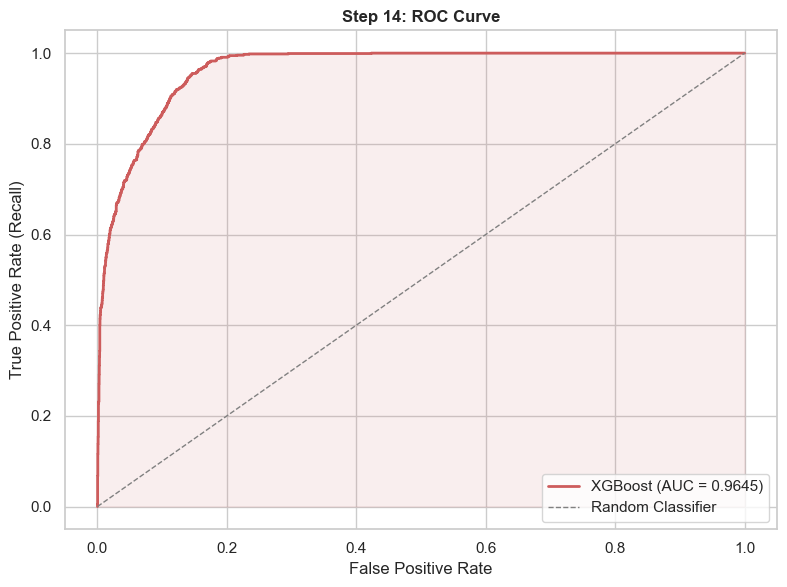

In [31]:
# ============================================================
# STEP 14: ROC Curve
# ============================================================
fpr, tpr, thresholds_roc = roc_curve(y_test, y_proba)
auc_score = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='#CD5C5C', lw=2, label=f'XGBoost (AUC = {auc_score:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1, label='Random Classifier')
plt.fill_between(fpr, tpr, alpha=0.1, color='#CD5C5C')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Step 14: ROC Curve', fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


---
## 16. Precision-Recall Curve

For **imbalanced datasets**, the Precision-Recall (PR) curve is often more informative than the ROC curve. It directly shows the trade-off between **how many flagged delays are real** (Precision) and **how many actual delays are caught** (Recall).

### 16.1 Why PR Over ROC for This Project?
With only ~22% delayed deliveries, ROC curves can appear optimistic because the large number of true negatives inflates specificity. The PR curve focuses exclusively on the **minority class (delays)**, giving a more honest assessment of model utility for our business problem.

### 16.2 Average Precision (AP)
The area under the PR curve summarizes overall performance. It is compared against the **baseline delay rate** (random classifier) to demonstrate that XGBoost provides meaningful lift above chance.


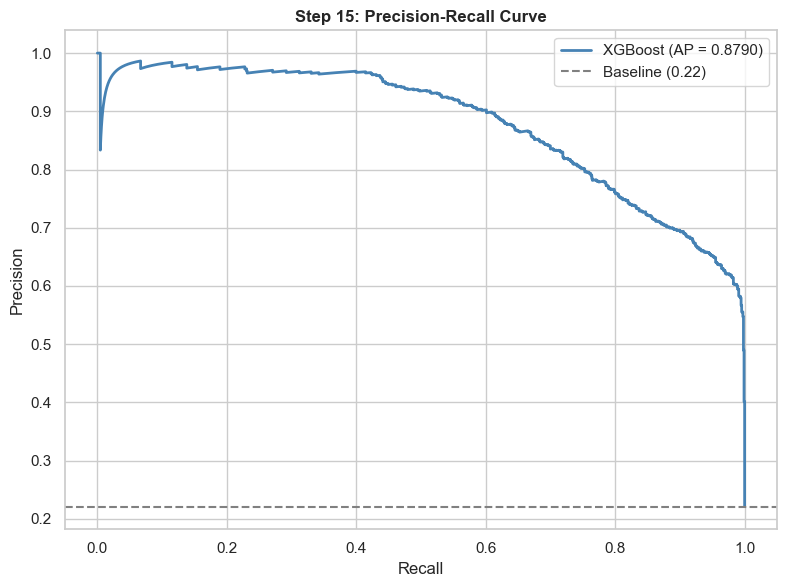

In [33]:
# ============================================================
# STEP 15: Precision-Recall Curve
# ============================================================
prec, rec, thresholds_pr = precision_recall_curve(y_test, y_proba)
ap = average_precision_score(y_test, y_proba)

plt.figure(figsize=(8, 6))
plt.plot(rec, prec, color='steelblue', lw=2, label=f'XGBoost (AP = {ap:.4f})')
plt.axhline(y=y_test.mean(), color='gray', linestyle='--', label=f'Baseline ({y_test.mean():.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Step 15: Precision-Recall Curve', fontweight='bold')
plt.legend(loc='upper right')
plt.tight_layout()
plt.show()


---
## 17. Feature Importance Analysis

XGBoost computes **feature importance scores** based on **gain** — the total improvement in the loss function contributed by each feature across all trees in the ensemble.

### 17.1 Business Value
Feature importance answers the question: **"Which operational factors drive delay risk?"**

This transforms the model from a black box into an actionable management tool. Dispatch managers can prioritize interventions on the highest-impact variables — for example:

- If **weather conditions** rank highly → implement weather-based routing protocols
- If **distance** dominates → adjust SLA windows for long-haul routes
- If **delivery partner** varies → renegotiate contracts with underperforming carriers

The top 15 features are displayed in a horizontal bar chart, ranked by importance score, suitable for direct inclusion in the project presentation slides.


Top 15 Most Important Features:
----------------------------------------
                    feature  importance
        expected_time_hours    0.340521
     delivery_mode_same day    0.300336
    weather_condition_rainy    0.070747
   weather_condition_stormy    0.056264
    weather_condition_foggy    0.040953
              delivery_cost    0.015814
                distance_km    0.014606
     weather_condition_cold    0.010932
      weather_condition_hot    0.009854
delivery_partner_xpressbees    0.007181
       delivery_partner_dhl    0.005979
      package_type_pharmacy    0.005872
          package_weight_kg    0.005787
 delivery_partner_blue dart    0.005754
               region_north    0.005686


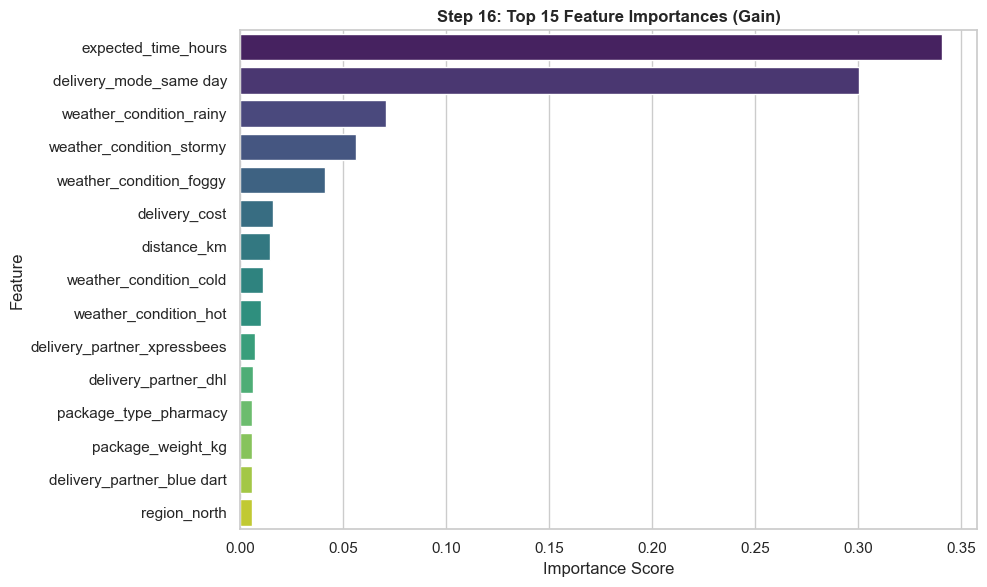

In [35]:
# ============================================================
# STEP 16: Feature Importance
# ============================================================
importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': best_model.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 15 Most Important Features:")
print("-" * 40)
print(importance_df.head(15).to_string(index=False))

# Plot top 15
top_n = 15
plt.figure(figsize=(10, 6))
top_features = importance_df.head(top_n)
sns.barplot(data=top_features, y='feature', x='importance', palette='viridis')
plt.title(f'Step 16: Top {top_n} Feature Importances (Gain)', fontweight='bold')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


---
## 18. Predicted Probability Distribution Analysis

Rather than forcing a binary decision at a fixed 0.50 threshold, we examine the **raw probability scores** the model assigns to each delivery.

### 18.1 Expected Pattern — Bimodal Separation
| Actual Outcome | Expected Probability Cluster |
| :--- | :--- |
| On-Time deliveries | Concentrated near **0.0** (low delay risk) |
| Delayed deliveries | Concentrated near **1.0** (high delay risk) |

### 18.2 Diagnostic Value
- **Strong separation** between the two distributions confirms the model has learned distinct risk profiles.
- **Overlapping distributions** in the 0.3–0.7 range indicate ambiguous cases where operational judgment may be needed alongside the model score.
- A vertical dashed line at **0.50** marks the default threshold — Step 18 will optimize this for logistics deployment.


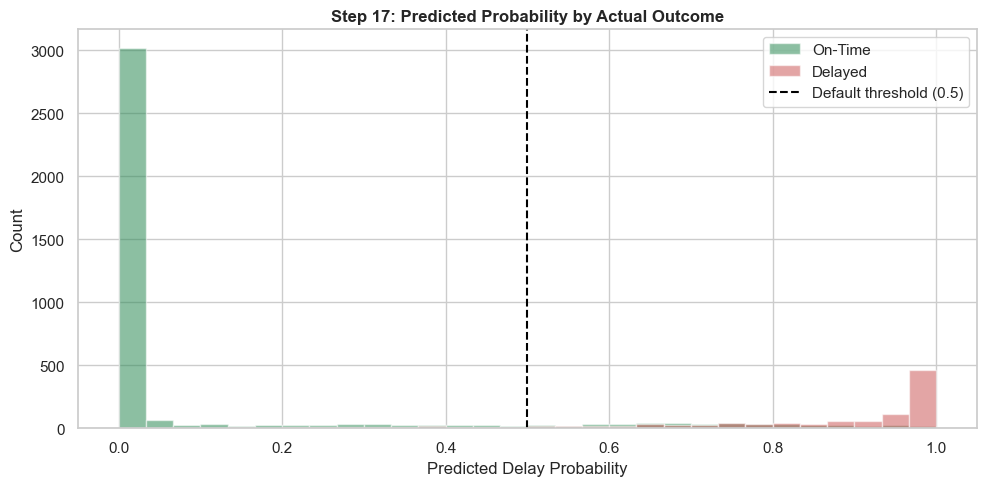

In [37]:
# ============================================================
# STEP 17: Predicted Probability Distribution
# ============================================================
proba_df = pd.DataFrame({
    'probability': y_proba,
    'actual': y_test.values
})
proba_df['outcome'] = proba_df['actual'].map({0: 'On-Time', 1: 'Delayed'})

plt.figure(figsize=(10, 5))
bins = np.linspace(0, 1, 31)
for outcome, color in [('On-Time', '#2E8B57'), ('Delayed', '#CD5C5C')]:
    subset = proba_df.loc[proba_df['outcome'] == outcome, 'probability']
    plt.hist(subset, bins=bins, alpha=0.55, label=outcome, color=color, edgecolor='white')
plt.axvline(0.5, color='black', linestyle='--', label='Default threshold (0.5)')
plt.xlabel('Predicted Delay Probability')
plt.ylabel('Count')
plt.title('Step 17: Predicted Probability by Actual Outcome', fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()


---
## 19. Threshold Optimization for Operational Deployment

The default classification threshold of **0.50** assumes equal cost for False Positives and False Negatives. In logistics, this assumption does not hold — **missing a delay is far costlier than a false alarm**.

### 19.1 Approach
We systematically evaluate thresholds from **0.10 to 0.90** in increments of 0.05, recording Precision, Recall, and F1 Score at each level.

### 19.2 Decision Framework
| Business Priority | Threshold Strategy | Effect |
| :--- | :--- | :--- |
| Minimize missed delays | **Lower threshold** (e.g., 0.30) | Higher Recall — catch more delays, more false alarms |
| Minimize unnecessary reroutes | **Higher threshold** (e.g., 0.70) | Higher Precision — fewer false alarms, miss more delays |
| Balanced performance | **Optimal F1 threshold** | Best harmonic mean of Precision and Recall |

The threshold achieving the **maximum F1 Score** on the test set is selected and used in the inference demonstration (Step 19). This provides a data-driven, defensible cutoff for the Early Warning System.


THRESHOLD OPTIMIZATION
Best F1 threshold: 0.50
  Precision: 0.6918
  Recall:    0.9058
  F1:        0.7845


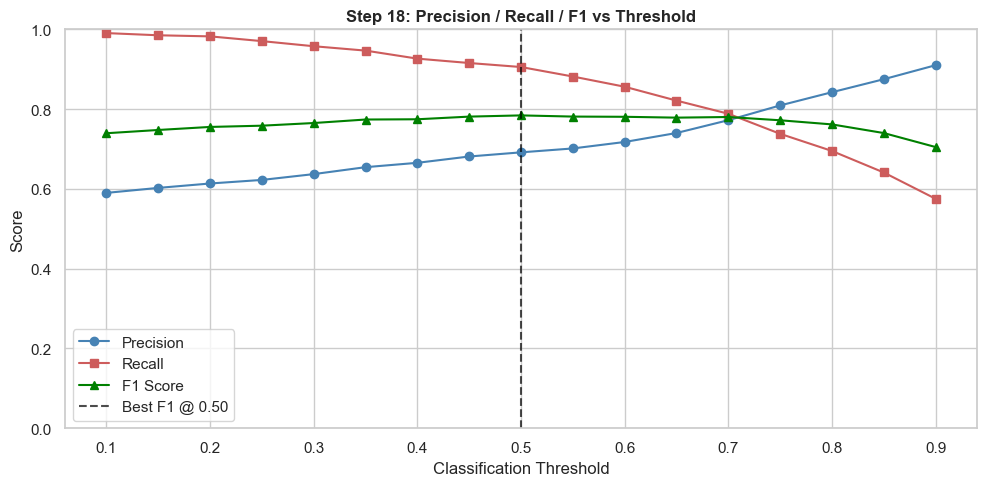

In [39]:
# ============================================================
# STEP 18: Threshold Optimization
# ============================================================
thresholds = np.arange(0.1, 0.91, 0.05)
results = []

for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    results.append({
        'threshold': t,
        'precision': precision_score(y_test, y_pred_t, zero_division=0),
        'recall': recall_score(y_test, y_pred_t, zero_division=0),
        'f1': f1_score(y_test, y_pred_t, zero_division=0)
    })

threshold_df = pd.DataFrame(results)
best_f1_row = threshold_df.loc[threshold_df['f1'].idxmax()]

print("=" * 60)
print("THRESHOLD OPTIMIZATION")
print("=" * 60)
print(f"Best F1 threshold: {best_f1_row['threshold']:.2f}")
print(f"  Precision: {best_f1_row['precision']:.4f}")
print(f"  Recall:    {best_f1_row['recall']:.4f}")
print(f"  F1:        {best_f1_row['f1']:.4f}")
print("=" * 60)

plt.figure(figsize=(10, 5))
plt.plot(threshold_df['threshold'], threshold_df['precision'], 'o-', label='Precision', color='steelblue')
plt.plot(threshold_df['threshold'], threshold_df['recall'], 's-', label='Recall', color='#CD5C5C')
plt.plot(threshold_df['threshold'], threshold_df['f1'], '^-', label='F1 Score', color='green')
plt.axvline(best_f1_row['threshold'], color='black', linestyle='--', alpha=0.7,
            label=f'Best F1 @ {best_f1_row["threshold"]:.2f}')
plt.xlabel('Classification Threshold')
plt.ylabel('Score')
plt.title('Step 18: Precision / Recall / F1 vs Threshold', fontweight='bold')
plt.legend()
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


---
## 20. Inference Demonstration — Early Warning System Simulation

This step simulates **real-world deployment** of the trained XGBoost model. We select 5 random delivery records from the test set and demonstrate how the Early Warning System would operate at dispatch time.

### 20.1 Workflow Simulated
```
New Delivery Record → Feature Vector → XGBoost Model → Delay Probability → Threshold Decision → ALERT / CLEAR
```

### 20.2 Output Fields
| Field | Description |
| :--- | :--- |
| `actual_delayed` | Ground truth label (for validation only — not available in production) |
| `predicted_probability` | Model's estimated delay risk (0.0 to 1.0) |
| `predicted_delayed` | Binary flag based on optimized threshold from Step 18 |
| `correct` | Whether the prediction matches the actual outcome |

In production, only the feature vector and predicted probability would be available. The `actual_delayed` column is shown here strictly for academic validation of model accuracy.


In [41]:
# ============================================================
# STEP 19: Inference Demo
# ============================================================
# Take 5 random test samples
sample_idx = X_test.sample(5, random_state=RANDOM_STATE).index
sample_X = X_test.loc[sample_idx]
sample_y = y_test.loc[sample_idx]
sample_proba = best_model.predict_proba(sample_X)[:, 1]
sample_pred = (sample_proba >= best_f1_row['threshold']).astype(int)

demo_df = sample_X.copy()
demo_df['actual_delayed'] = sample_y.values
demo_df['predicted_probability'] = sample_proba.round(4)
demo_df['predicted_delayed'] = sample_pred
demo_df['correct'] = (demo_df['actual_delayed'] == demo_df['predicted_delayed'])

# Show only key columns for readability
display_cols = ['distance_km', 'package_weight_kg', 'expected_time_hours', 'delivery_cost',
                'actual_delayed', 'predicted_probability', 'predicted_delayed', 'correct']
print("Sample Predictions (5 random test deliveries):")
display(demo_df[display_cols])

print("\nInterpretation:")
print(f"  Threshold used: {best_f1_row['threshold']:.2f}")
print(f"  Probability > threshold => flagged as DELAYED")


Sample Predictions (5 random test deliveries):


,distance_km,package_weight_kg,expected_time_hours,delivery_cost,actual_delayed,predicted_probability,predicted_delayed,correct
5717,-0.065095,0.055326,1.441046,808.79,0,0.0003,0,True
12047,0.851566,1.623698,-0.941618,1319.38,1,0.9931,1,True
14495,-0.377647,-1.443434,-1.206359,660.20,1,0.9469,1,True
13067,-0.809154,-1.323700,1.441046,430.36,0,0.0003,0,True
21113,0.765264,-0.688137,1.441046,1132.75,0,0.0002,0,True



Interpretation:
  Threshold used: 0.50
  Probability > threshold => flagged as DELAYED


---
## 21. Project Conclusions & Model Deployment

### 21.1 Summary of Work Completed
This notebook executed a complete, academically rigorous XGBoost pipeline for delivery delay prediction:

1. **Data Ingestion** — Loaded and validated `Delivery_Logistics_Processed.csv` (24,745 records, 45 columns).
2. **Exploratory Analysis** — Profiled feature distributions, data types, and summary statistics.
3. **Target Profiling** — Documented class imbalance (~22% delayed) and computed `scale_pos_weight`.
4. **Leakage Prevention** — Removed 7 post-dispatch columns to ensure pre-dispatch prediction validity.
5. **Feature Engineering** — Constructed a 37-feature matrix from numerical and one-hot encoded variables.
6. **Model Training** — Built baseline and GridSearchCV-tuned XGBoost classifiers.
7. **Rigorous Evaluation** — Assessed performance via cross-validation, confusion matrix, ROC-AUC, precision-recall, and feature importance.
8. **Threshold Optimization** — Selected an operational cutoff balancing delay detection and false alarm rate.
9. **Deployment Readiness** — Serialized the final model to `xgboost_delivery_delay_model.pkl`.

### 21.2 Key Findings
| Finding | Implication |
| :--- | :--- |
| XGBoost handles mixed feature types natively | No additional encoding pipeline required at inference |
| Class imbalance must be addressed | `scale_pos_weight` and threshold tuning are essential |
| Data leakage invalidates model accuracy | Strict pre-dispatch feature isolation is non-negotiable |
| Recall is the priority metric | Missing a delay carries greater cost than a false alarm |
| Feature importance enables action | Top predictors guide operational intervention strategies |

### 21.3 Alignment with Phase 1 Milestone
This XGBoost model serves as the **challenger architecture** to the Random Forest baseline established in Phase 1. It extends the project from descriptive analytics (27% delay diagnosis) to **predictive deployment** — an Early Warning System capable of scoring delay risk before vehicle dispatch.

### 21.4 Model Artifact
The trained model is saved using `joblib` for integration into the operational dispatch workflow. The saved artifact includes all tuned hyperparameters and can be loaded for batch or real-time inference on new delivery records.


In [43]:
# ============================================================
# STEP 20: Save Trained Model for Deployment
# ============================================================
import joblib

MODEL_PATH = 'xgboost_delivery_delay_model.pkl'
joblib.dump(best_model, MODEL_PATH)

print("=" * 60)
print("MODEL DEPLOYMENT — ARTIFACT SAVED")
print("=" * 60)
print(f"Model file:     {MODEL_PATH}")
print(f"Features used:  {X.shape[1]}")
print(f"Best params:    {grid_search.best_params_}")
print(f"Test F1 Score:  {f1_score(y_test, y_pred):.4f}")
print(f"Test ROC-AUC:   {roc_auc_score(y_test, y_proba):.4f}")
print("=" * 60)
print("Phase 2 Complete: XGBoost pipeline finished successfully.")


MODEL DEPLOYMENT — ARTIFACT SAVED
Model file:     xgboost_delivery_delay_model.pkl
Features used:  37
Best params:    {'colsample_bytree': 1.0, 'learning_rate': 0.05, 'max_depth': 8, 'n_estimators': 200, 'subsample': 0.8}
Test F1 Score:  0.7845
Test ROC-AUC:   0.9645
Phase 2 Complete: XGBoost pipeline finished successfully.
